# 3 - Entrenamiento de Modelos y Exportación ONNX (FinanceAI)

1. Simulación > 2. EDA > **3. Entrenamiento**

### Propósito del cuaderno
Este cuaderno es el núcleo de Machine Learning del proyecto. Cumple cuatro objetivos clave:
1. **Entrenar el clasificador de perfiles financieros:** Modelo basado en árboles (*Random Forest*) que diagnostica el estado del usuario (`Saludable`, `En observación`, `En riesgo`).
2. **Entrenar el clasificador de transacciones (NLP):** Pipeline de procesamiento de lenguaje natural (*TF-IDF + Regresión Logística*) para clasificar texto bancario libre en 10 categorías.
3. **Auditar el sobreajuste y falsos positivos:** Evaluación rigurosa en sets ciegos (Validación y Test) con umbrales de certeza para derivar casos dudosos a *Revisión Manual*.
4. **Exportar a formato estándar ONNX:** Serializar los modelos matemáticos y generar el contrato de metadatos (`metadata.json`) para inferencia nativa en Java (Spring Boot) sin dependencias de Python en producción.

### Preparación del entorno y dependencias

Importamos las librerías de modelado (*scikit-learn*), procesamiento de lenguaje natural (*nltk*), análisis gráfico (*seaborn/matplotlib*) y el convertidor a formato universal ONNX (*skl2onnx*).

In [1]:
import pandas as pd

import nltk
from nltk.corpus import stopwords
import certifi
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
nltk.download('stopwords', quiet=True)
spanish_stop_words = stopwords.words('spanish')
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skl2onnx import to_onnx
from skl2onnx.common.data_types import StringTensorType, FloatTensorType

SEED = 42
print("Librerías de ML y conversión ONNX cargadas correctamente.")

Librerías de ML y conversión ONNX cargadas correctamente.


## 1. Carga de datos y partición analítica (Train / Val / Test)

### Estrategia de partición:
* **Para Perfiles de Usuario:** Partición transversal agrupada (Cross-sectional holdout: 60% Train, 20% Val, 20% Test).
* **Para Transacciones (NLP):** Partición temporal (*Out-of-Time*). El modelo aprende con el pasado (Ene-Ago, ~574k registros) y se evalúa de manera ciega sobre el futuro (Nov-Dic, ~145k registros) para simular el comportamiento en producción.

In [2]:
df_usr = pd.read_csv('data/usuarios.csv')
df_txn = pd.read_csv('data/transacciones.csv')

# splits para usuarios (_u)
train_u = df_usr[df_usr['split'] == 'train'].copy()
val_u = df_usr[df_usr['split'] == 'val'].copy()
test_u = df_usr[df_usr['split'] == 'test'].copy()

# splits para transacciones (_t)
train_t = df_txn[df_txn['split'] == 'train'].copy()
val_t = df_txn[df_txn['split'] == 'val'].copy()
test_t = df_txn[df_txn['split'] == 'test'].copy()


print(f"Revisión:\nUsuarios (Train/Val/Test): {len(train_u)} / {len(val_u)} / {len(test_u)}")
print(f"Transacciones (Train/Val/Test): {len(train_t)} / {len(val_t)} / {len(test_t)}")

Revisión:
Usuarios (Train/Val/Test): 1072 / 360 / 368
Transacciones (Train/Val/Test): 574511 / 144587 / 144902


## 2. Modelo 1: Clasificador de perfiles financieros (Random Forest)

### ¿Qué buscamos?
Predecir la salud financiera a partir de 3 variables cuantitativas: `ingreso_mensual`, `nivel_endeudamiento` y el hábito de ahorro numérico (`ahorro_num`).

### Criterios técnicos de modelado:
* **Balanceo de clases (`class_weight='balanced'`):** Ajusta los pesos de penalización inversamente proporcionales a las frecuencias de clase, garantizando que la minoría crítica (*En riesgo*) sea detectada con máxima sensibilidad.
* **Matriz de Confusión Normalizada (`normalize='true'`):** Muestra proporciones de acierto (0 a 1.0) en vez de recuentos absolutos, permitiendo una visualización limpia e imparcial del rendimiento por clase.

A)--- Reporte en VAL (Ajuste) ---
                precision    recall  f1-score   support

En observacion       1.00      1.00      1.00        64
     En riesgo       1.00      1.00      1.00        32
     Saludable       1.00      1.00      1.00       264

      accuracy                           1.00       360
     macro avg       1.00      1.00      1.00       360
  weighted avg       1.00      1.00      1.00       360


B)--- Reporte en TEST (calificación final) ---
                precision    recall  f1-score   support

En observacion       0.98      1.00      0.99        45
     En riesgo       1.00      1.00      1.00        31
     Saludable       1.00      1.00      1.00       292

      accuracy                           1.00       368
     macro avg       0.99      1.00      1.00       368
  weighted avg       1.00      1.00      1.00       368



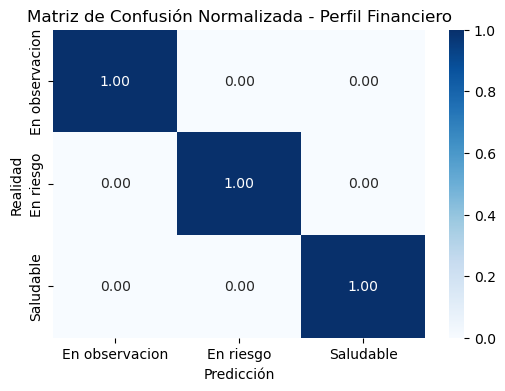

In [3]:
# Preprocesamiento (conversión numérica compatible con java)
mapeo_ahorro = {'Ninguna': 0.0, 'Baja': 1.0, 'Media': 2.0, 'Alta': 3.0}

# Servir los datos para el entrenamiento
# Preparar los datos brutos del CSV para que el algoritmo matemático pueda digerirlos antes de entrenar el modelo
def prepare_features(df):
    df_prep = df.copy() # Hace una copia de seguridad de la tabla de datos para no arruinar el archivo original
    df_prep['ahorro_num'] = df_prep['frecuencia_ahorro'].map(mapeo_ahorro) # traduce palabras a números
    return df_prep[['ingreso_mensual', 'nivel_endeudamiento', 'ahorro_num']], df_prep['perfil_financiero'] # separan la tabla en dos partes y devuelve features y labels

X_train_u, y_train_u = prepare_features(train_u)
X_val_u, y_val_u = prepare_features(val_u)
X_test_u, y_test_u = prepare_features(test_u)

# Entrenamos dando prioridad a los casos 'en riesgo'
profiler_model = RandomForestClassifier(n_estimators=20, max_depth=5, class_weight='balanced', random_state=SEED) # subido el max depth de 5 a 8
profiler_model.fit(X_train_u, y_train_u)

# Evaluación ciega sobre set de validación y test
y_val_pred = profiler_model.predict(X_val_u)
y_test_pred = profiler_model.predict(X_test_u)

print("A)--- Reporte en VAL (Ajuste) ---")
print(classification_report(y_val_u, y_val_pred))

print("\nB)--- Reporte en TEST (calificación final) ---")
print(classification_report(y_test_u, y_test_pred))# Graficar matriz de confusión del perfil financiero
cm_prof = confusion_matrix(y_test_u, y_test_pred, normalize='true')
plt.figure(figsize=(6,4))
sns.heatmap(cm_prof, annot=True, fmt='.2f', cmap='Blues', xticklabels=profiler_model.classes_, yticklabels=profiler_model.classes_)
plt.title('Matriz de Confusión Normalizada - Perfil Financiero')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()







## 3. Modelo 2: Clasificador de transacciones (NLP: TF-IDF + Regresión Logística)

### ¿Qué buscamos?
Convertir texto bancario no estructurado (ej. *'deb supermercado'*, *'cuota gimnasio'*) en vectores numéricos y predecir su categoría.

### Criterios técnicos del Pipeline:
1. **`TfidfVectorizer(ngram_range=(1, 2))`:** Captura unigramas y bigramas preservando el contexto sintáctico (ej. *'compra coto'*), filtrando *stopwords* en español con un vocabulario óptimo de 5,000 términos.
2. **`LogisticRegression(C=1.0)`:** Clasificador lineal rápido, probabilístico y con bajo consumo de memoria.
3. **Política de umbral de certeza (`evaluar_con_umbral`):** Si la probabilidad predicha es $< 0.80$, la transacción se desvía a `Revision Manual` para mitigar el impacto de falsos positivos en producción.

In [4]:
# Separamos los textos de las categorías correctas
X_train_t = train_t['descripcion']
y_train_t = train_t['categoria']

X_val_t = val_t['descripcion']
y_val_t = val_t['categoria']

X_test_t = test_t['descripcion']
y_test_t = test_t['categoria']

# Pipeline Completo
# Entrenamiento automático
print("Iniciando el entrenamiento directo (usando los mejores parámetros conocidos)...")
# 1. Paso a paso del modelo
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=spanish_stop_words, ngram_range=(1, 2), max_features=5000)),
    ('clf', LogisticRegression(random_state=SEED, C=1.0, max_iter=1000))
])

# Al no usar GridSearchCV, entrenar sobre todas las filas tarda solo unos segundos
nlp_pipeline.fit(X_train_t, y_train_t)
best_model = nlp_pipeline

print("Evaluando el modelo óptimo con distintos umbrales de probabilidad...")
def evaluar_con_umbral(modelo, X, y_true, umbral):
    probas = modelo.predict_proba(X)
    clases = modelo.classes_
    y_pred = []
    
    for p in probas:
        idx_max = np.argmax(p)
        if p[idx_max] >= umbral:
            y_pred.append(clases[idx_max])
        else:
            y_pred.append("Revision Manual")
            
    print(f"\n--- Reporte NLP con Umbral >= {umbral} ---")
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred, zero_division=0))

umbrales = [0.4, 0.6, 0.8]
print("\n--- Resultados en Validación (ciego para el modelo) ---")
for u in umbrales:
    evaluar_con_umbral(best_model, X_val_t, y_val_t, u)

print("\n--- Resultados en Test (calificación final) ---")
for u in umbrales:
    evaluar_con_umbral(best_model, X_test_t, y_test_t, u)







Iniciando el entrenamiento directo (usando los mejores parámetros conocidos)...
Evaluando el modelo óptimo con distintos umbrales de probabilidad...

--- Resultados en Validación (ciego para el modelo) ---

--- Reporte NLP con Umbral >= 0.4 ---
                   precision    recall  f1-score   support

     Alimentacion       0.91      0.96      0.93     27011
        Educacion       0.91      0.82      0.86      7913
Electrodomesticos       0.91      0.83      0.87      7800
        Inversion       0.91      0.74      0.81      5326
             Ocio       0.91      0.91      0.91     14494
  Revision Manual       0.00      0.00      0.00         0
            Salud       0.91      0.82      0.86      7857
        Servicios       0.90      0.96      0.93     27547
       Transporte       0.90      0.92      0.91     17303
       Vestimenta       0.91      0.80      0.85      8269
         Vivienda       0.91      0.93      0.92     21067

         accuracy                           0

## 4. Exportación (ONNX)
Guardamos nuestros modelos terminados en formato ONNX. Este estándar es genial porque nos permite llevar la IA directamente a nuestra aplicación en Java de forma muy sencilla.

In [5]:
os.makedirs('models', exist_ok=True)
os.makedirs('../shared-models', exist_ok=True)

# Exportar modelo perfil (espera matriz bidimensional de 3 floats)
initial_type_prof = [('float_input', FloatTensorType([None, 3]))]
onnx_prof = to_onnx(profiler_model, initial_types=initial_type_prof, target_opset=12, options={type(profiler_model): {'zipmap': False}})

# Exportamos el modelo de textos
initial_type_nlp = [('string_input', StringTensorType([None, 1]))]
onnx_nlp = to_onnx(nlp_pipeline, initial_types=initial_type_nlp, target_opset=12)

for path in ['models/', '../shared-models/']:
    with open(f"{path}modelo_perfil.onnx", 'wb') as f:
        f.write(onnx_prof.SerializeToString())
    with open(f"{path}modelo_transacciones.onnx", 'wb') as f:
        f.write(onnx_nlp.SerializeToString())

print("Modelos exportados a models/ y shared-models/.")

Modelos exportados a models/ y shared-models/.


In [6]:
# Creación del metadata.json
# Se registran dinámicamente las clases del modelo para no codificarlas fijos (hardcode) en Java

metadata = {
    "model_version": "2.0.0",
    "categories": list(nlp_pipeline.classes_),
    "profiles": list(profiler_model.classes_),
    "transacciones_model": {
        "onnx_input_name": "string_input",
        "onnx_output_name": "output_label",
        "categories": list(nlp_pipeline.classes_)
    },
    "perfil_model": {
        "onnx_input_name": "float_input",
        "onnx_output_name": "output_label",
        "profiles": list(profiler_model.classes_)
    }
}

for path in ['models/', '../shared-models/']:
    with open(f"{path}metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Contrato de Metadatos creado y exportado:")
print(json.dumps(metadata, indent=2))

Contrato de Metadatos creado y exportado:
{
  "model_version": "2.0.0",
  "categories": [
    "Alimentacion",
    "Educacion",
    "Electrodomesticos",
    "Inversion",
    "Ocio",
    "Salud",
    "Servicios",
    "Transporte",
    "Vestimenta",
    "Vivienda"
  ],
  "profiles": [
    "En observacion",
    "En riesgo",
    "Saludable"
  ],
  "transacciones_model": {
    "onnx_input_name": "string_input",
    "onnx_output_name": "output_label",
    "categories": [
      "Alimentacion",
      "Educacion",
      "Electrodomesticos",
      "Inversion",
      "Ocio",
      "Salud",
      "Servicios",
      "Transporte",
      "Vestimenta",
      "Vivienda"
    ]
  },
  "perfil_model": {
    "onnx_input_name": "float_input",
    "onnx_output_name": "output_label",
    "profiles": [
      "En observacion",
      "En riesgo",
      "Saludable"
    ]
  }
}


In [7]:
from sklearn.metrics import accuracy_score
y_val_pred = best_model.predict(X_val_t)
print(f"Score final (Accuracy en validación): {accuracy_score(y_val_t, y_val_pred):.4f}")

Score final (Accuracy en validación): 0.9066


---

## Prueba ONNX categorías

import onnxruntime as ort
import numpy as np

# ONNX ya trae su propio diccionario integrado
session = ort.InferenceSession("../shared-models/modelo_transacciones.onnx")
input_name = session.get_inputs()[0].name

print(" Modelo ONNX cargado. Escribe una transacción para probar su inteligencia.")
print("Escribe 'salir' para terminar.\n")

while True:
    texto = input(" Ingresa un gasto (ej. 'compra super', 'cuota osde'): ")
    
    if texto.lower() == 'salir':
        break
        
    # Convertir el texto al formato matricial que espera ONNX
    input_data = np.array([[texto]], dtype=object)
    
    # Hacer la inferencia
    resultado = session.run(None, {input_name: input_data})
    
    # Como el modelo ya escupe el texto directo, simplemente lo imprimimos
    categoria = resultado[0][0]
    
    print(f" Inteligencia Artificial dice: {categoria}\n")

## 🕹️ Prueba de Perfiles
**Algunos ejemplos que puedes intentar:**

- **Gana bien, pero no ahorra:** Ingreso alto, Deuda normal, Ahorro nulo ➡️ *En observación*.
- **Sueldo bajo, pero muy prolijo:** Ingreso bajo, Deuda controlada, Ahorro alto ➡️ *Saludable*.
- **Gastador compulsivo:** Ingreso medio, Deuda del 38% ➡️ *En riesgo*.

import onnxruntime as ort
import numpy as np

# Cargar el "cerebro" ONNX del perfilador
session_perfil = ort.InferenceSession("../shared-models/modelo_perfil.onnx")
input_name_perfil = session_perfil.get_inputs()[0].name

print(" Modelo de Perfilado ONNX cargado.")
print("Simulemos la economía de un usuario. Escribe 'salir' en cualquier momento para terminar.\\n")

# Diccionario interno que usa tu modelo para entender el texto del ahorro
mapeo_ahorro = {'ninguna': 0.0, 'baja': 1.0, 'media': 2.0, 'alta': 3.0}

while True:
    ingreso = input(" 1. Ingreso mensual (ej. 2500): ")
    if ingreso.lower() == 'salir': break
        
    deuda = input(" 2. Nivel de endeudamiento % (ej. 45 para 45%): ")
    if deuda.lower() == 'salir': break
        
    ahorro = input(" 3. Hábito de ahorro (Ninguna, Baja, Media, Alta): ").lower()
    if ahorro == 'salir': break

    try:
        # Convertir los inputs humanos a números flotantes
        ingreso_float = float(ingreso)
        deuda_float = float(deuda)
        ahorro_float = mapeo_ahorro.get(ahorro, 0.0) # Si escribe mal, asume Ninguna
        
        # ONNX exige una matriz 2D de tipo float32 estricto
        input_data = np.array([[ingreso_float, deuda_float, ahorro_float]], dtype=np.float32)
        
        # Hacer la inferencia
        resultado = session_perfil.run(None, {input_name_perfil: input_data})
        
        # Extraer el veredicto
        perfil_asignado = resultado[0][0]
        
        print(f"\n Diagnóstico de la IA: Usuario {perfil_asignado}\n")
        print("-" * 40)
        
    except ValueError:
        print("\n Error: Asegúrate de ingresar números válidos en Ingreso y Deuda.\n")

## 4. Consideraciones arquitectónicas, autocrítica y trabajo a futuro

Como parte de la madurez en ingeniería de software y ciencia de datos, es fundamental auditar las decisiones de diseño del proyecto, reconociendo qué elecciones fueron óptimas y qué áreas constituyen sobreingeniería o deuda técnica planificada:

---

### 1. Crítica al modelo de perfilado: ¿Machine Learning o Motor de Reglas?
* **El caso de sobreingeniería (Overengineering):** En este proyecto, el perfil financiero (`Saludable`, `En observación`, `En riesgo`) se dedujo en el Cuaderno 1 mediante fórmulas matemáticas y condicionales rígidos. Entrenar un *Random Forest* para reaprender una fórmula exacta que nosotros mismos programamos es técnicamente innecesario.
* **La solución óptima en producción:** El perfilado debería ejecutarse directamente en el Backend (Java/Spring Boot) mediante un **Motor de Reglas de Negocio (Rule Engine)** o una clase de servicio (`ProfileEvaluationService`) con lógica condicional simple. Esto reduce el consumo de memoria RAM (evita levantar sesiones ONNX innecesarias), responde en microsegundos y garantiza un 100% de exactitud determinista.
* **Justificación en el MVP:** Se mantuvo la exportación del modelo a ONNX como una prueba de concepto arquitectónica (*PoC*) para validar la tubería de tensores multidimensionales entre Scikit-Learn y Spring Boot.

---

### 2. El circuito de "Revisión Manual": Desacople operativo
* **Estado actual:** El clasificador de NLP implementa un umbral conservador de seguridad ($0.80$). Si una transacción es ambigua, el modelo la etiqueta como `Revision Manual` para proteger al usuario de falsos positivos.
* **Limitación en el MVP:** El Backend en Spring Boot puede persistir este estado en la base de datos MySQL (ej. `status = 'PENDIENTE_REVISION'`). Sin embargo, el MVP no incluye una interfaz web de administración (*Backoffice UI*) en Vue.js para que un operador humano audite y reclasifique esas transacciones.
* **Evolución (Versión 2.0):** Implementar un panel de auditoría humana con un ciclo de aprendizaje activo (*Active Learning*), donde las correcciones de los operadores sirvan para re-entrenar periódicamente el clasificador.

---

### 3. Evolución del modelo NLP (TF-IDF vs. Embeddings neuronales)
* **Por qué TF-IDF en el MVP:** Permite serialización nativa y ligera en ONNX sin dependencias pesadas de Python en Docker, ofreciendo tiempos de inferencia inferiores a 5 milisegundos por transacción.
* **Camino a futuro:** Evaluar modelos de representaciones densas (como *FastText* o transformadores compactos) si el volumen de vocabulario regional o la complejidad sintáctica de las descripciones requiere mayor comprensión contextual.